# 用 PINN 求解二维 Poisson 方程（对应书中 §5.2）

$$-\Delta u = 2\pi^2\sin(\pi x)\sin(\pi y),\quad (x,y)\in(0,1)^2,\quad u|_{\partial\Omega}=0,
\qquad u^*=\sin(\pi x)\sin(\pi y)$$

In [1]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

In [2]:
import math

def exact(xy):
    return torch.sin(math.pi * xy[:, :1]) * torch.sin(math.pi * xy[:, 1:])

def source(xy):
    return 2 * math.pi ** 2 * exact(xy)

net = nn.Sequential(
    nn.Linear(2, 64), nn.Tanh(),
    nn.Linear(64, 64), nn.Tanh(),
    nn.Linear(64, 64), nn.Tanh(),
    nn.Linear(64, 1),
)

def model(xy):
    x, y = xy[:, :1], xy[:, 1:]
    return x * (1 - x) * y * (1 - y) * net(xy)

In [3]:
def residual_loss(xy):
    xy = xy.clone().requires_grad_(True)
    u = model(xy)
    g = torch.autograd.grad(u, xy, torch.ones_like(u), create_graph=True)[0]
    uxx = torch.autograd.grad(g[:, :1], xy, torch.ones_like(u), create_graph=True)[0][:, :1]
    uyy = torch.autograd.grad(g[:, 1:], xy, torch.ones_like(u), create_graph=True)[0][:, 1:]
    return ((-(uxx + uyy) - source(xy)) ** 2).mean()

opt = torch.optim.Adam(net.parameters(), lr=1e-3)
for epoch in range(3001):
    xy = torch.rand(1000, 2)
    loss = residual_loss(xy)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if epoch % 500 == 0:
        print(f"epoch {epoch:5d}   loss = {loss.item():.3e}")

epoch     0   loss = 9.643e+01


epoch   500   loss = 5.234e+00


epoch  1000   loss = 2.963e-03


epoch  1500   loss = 9.863e-04


epoch  2000   loss = 4.448e-04


epoch  2500   loss = 2.844e-04


epoch  3000   loss = 1.852e-04


relative L2 error: 4.10e-05


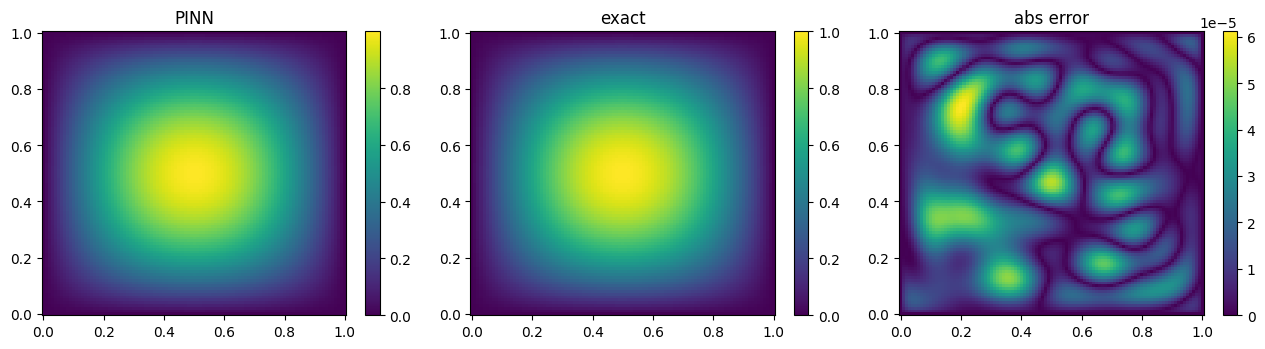

In [4]:
g = torch.linspace(0, 1, 101)
XX, YY = torch.meshgrid(g, g, indexing="xy")
P = torch.stack([XX.flatten(), YY.flatten()], dim=1)
with torch.no_grad():
    U = model(P).reshape(101, 101)
Ue = exact(P).reshape(101, 101)

print(f"relative L2 error: {(U - Ue).norm() / Ue.norm():.2e}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, Z, title in [(axes[0], U, "PINN"), (axes[1], Ue, "exact"),
                     (axes[2], (U - Ue).abs(), "abs error")]:
    im = ax.pcolormesh(XX, YY, Z, shading="auto")
    ax.set_title(title); plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()